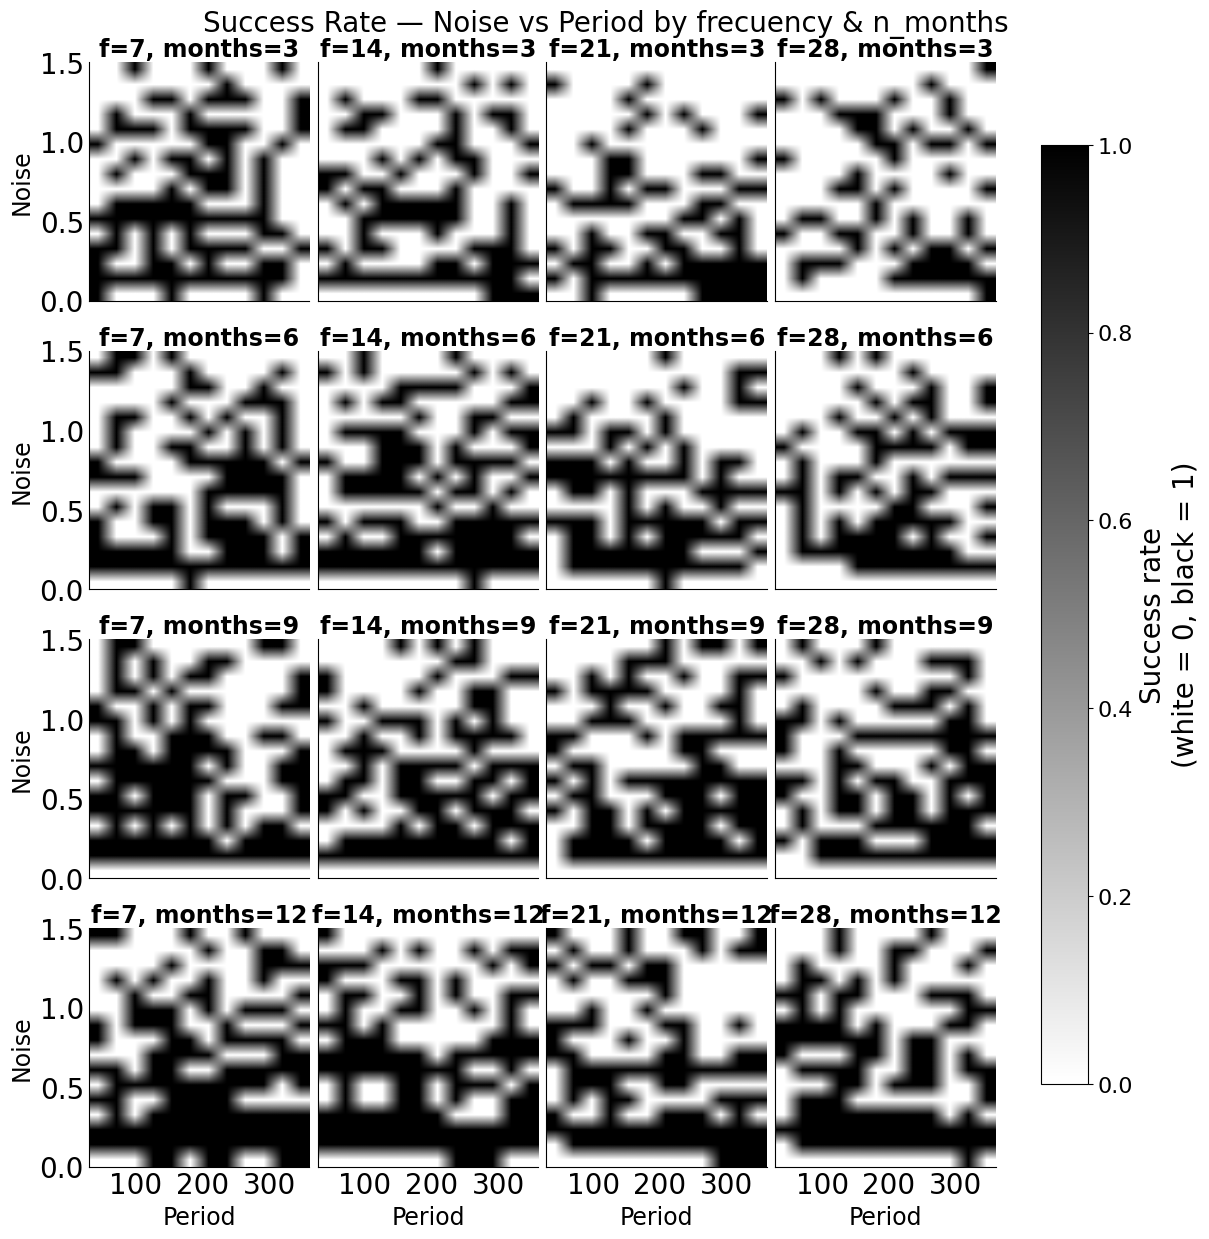

In [6]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ─────────────────────────────────────────────────────────────────────────────
#  Ajusta aquí tus tamaños de fuente (en puntos)
# ─────────────────────────────────────────────────────────────────────────────
size=20
BASE_FS           = size  # tamaño base de todo el texto
TITLE_FS          = 17  # títulos de cada subplot
LABEL_FS          = 17  # etiquetas de ejes
TICK_FS           = size  # etiquetas de ticks
CBAR_LABEL_FS     = size  # etiqueta de la colorbar
CBAR_TICK_FS      = 16  # ticks de la colorbar
SUPTITLE_FS       = size  # supertítulo global

# ─────────────────────────────────────────────────────────────────────────────
#  1) Configurar estilos globales con rcParams
# ─────────────────────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.size':        BASE_FS,       # fuente base
    'axes.titlesize':   TITLE_FS,      # títulos de subplots
    'axes.labelsize':   LABEL_FS,      # etiquetas de ejes
    'axes.titleweight': 'bold',
    'figure.titlesize': SUPTITLE_FS,   # suptitle
    'xtick.labelsize':  TICK_FS,       # ticks en x
    'ytick.labelsize':  TICK_FS,       # ticks en y
})

# ─────────────────────────────────────────────────────────────────────────────
#  2) Cargar y procesar datos
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv("data/sensibilidad/sensibilidad_010_000_08.csv")  # ajusta la ruta si es necesario

agg = (
    df.groupby(["frec_obs", "ruido", "periodo", "n_meses"], as_index=False)["ok"]
      .mean()
      .rename(columns={"ok": "tasa"})
)

freqs  = sorted(agg["frec_obs"].unique())
nmeses = sorted(agg["n_meses"].unique())

# ─────────────────────────────────────────────────────────────────────────────
#  3) Definir colormap
# ─────────────────────────────────────────────────────────────────────────────
cmap = LinearSegmentedColormap.from_list(
    "success_fail", ["white", "gray", "black"], N=256
)

# ─────────────────────────────────────────────────────────────────────────────
#  4) Crear subplots
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    nrows=len(nmeses), ncols=len(freqs),
    figsize=(len(freqs) * 3, len(nmeses) * 3),
    sharex=True, sharey=True,
    constrained_layout=True
)

# ─────────────────────────────────────────────────────────────────────────────
#  5) Dibujar cada heatmap
# ─────────────────────────────────────────────────────────────────────────────
for i, nm in enumerate(nmeses):
    for j, f in enumerate(freqs):
        ax = axes[i, j]
        sub = agg[(agg["frec_obs"] == f) & (agg["n_meses"] == nm)]
        grid = (
            sub.pivot_table(index="ruido", columns="periodo", values="tasa")
               .sort_index()
               .sort_index(axis=1)
        )
        arr = (
            grid.ffill(axis=0).bfill(axis=0)
                .ffill(axis=1).bfill(axis=1)
                .values
        )
        im = ax.imshow(
            arr,
            origin="lower",
            aspect="auto",
            cmap=cmap,
            vmin=0, vmax=1,
            interpolation="bilinear",
            extent=[
                grid.columns.min(), grid.columns.max(),
                grid.index.min(),  grid.index.max(),
            ],
        )

        # Título de cada subplot
        ax.set_title(f"f={f}, months={nm}", pad=4)

        # Etiquetas de ejes (solo en los bordes)
        if i == len(nmeses) - 1:
            ax.set_xlabel("Period")
        if j == 0:
            ax.set_ylabel("Noise")

        # Quitar líneas de ticks y bordes superiores/derechos
        ax.tick_params(which="both", length=0)
        ax.spines[["top", "right"]].set_visible(False)

# ─────────────────────────────────────────────────────────────────────────────
#  6) Añadir colorbar
# ─────────────────────────────────────────────────────────────────────────────
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label(
    "Success rate\n(white = 0, black = 1)",
    fontsize=CBAR_LABEL_FS
)
cbar.ax.tick_params(labelsize=CBAR_TICK_FS)

# ─────────────────────────────────────────────────────────────────────────────
#  7) Supertítulo global y guardado
# ─────────────────────────────────────────────────────────────────────────────
fig.suptitle(
    "Success Rate — Noise vs Period by frecuency & n_months",
    y=1.02
)
plt.savefig('plots/sensibilidad_4x4_010_000_08.png', bbox_inches='tight', dpi=600)
plt.show()
